In [1]:
import numpy as np
import pandas as pd

from bootstrap_diagnostics import (
    Bootstrap,
    CircularBlockResampler,
    HierarchicalResampler,
    IIDResampler,
    MovingBlockResampler,
)

In [2]:
rng = np.random.default_rng(0)
data = rng.standard_normal((15, 1))
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True)

bs._bootstrap_replicates(5, rng, n_jobs=2, estimate_shape=(1,))

array([[-0.10582374],
       [-0.53233865],
       [-0.2693054 ],
       [-0.11075487],
       [-0.22981896]])

In [23]:
rng = np.random.default_rng(0)
data = rng.standard_normal(10)
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=False)

bs.variance(n_resamples=10000, n_jobs=-1, seed=42)

0.05559183378723394

In [24]:
rng = np.random.default_rng(0)
data = rng.standard_normal(10)
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True)

bs.variance(n_resamples=10000, n_jobs=-1, seed=42)

0.05559183378723394

In [3]:
rng = np.random.default_rng(0)
data = rng.standard_normal((15, 1))
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True)

bs._bootstrap_replicates(5, rng, n_jobs=2, estimate_shape=(1,))

array([[-0.10582374],
       [-0.53233865],
       [-0.2693054 ],
       [-0.11075487],
       [-0.22981896]])

In [4]:
data = resampler.draw_batch_sample(2, rng)
data.mean(axis=1)

array([[-0.13999819],
       [-0.29906441]])

In [5]:
data[1].mean(axis=0)

array([-0.29906441])

In [6]:
data.mean(axis=0)

array([[-0.46126345],
       [ 0.58594759],
       [-0.56009036],
       [ 0.00857409],
       [-0.44215795],
       [-0.41792005],
       [-0.31249941],
       [-1.51438301],
       [ 0.54260419],
       [-0.37723052],
       [-0.08873284],
       [-0.62327446],
       [-0.05694577],
       [ 0.34087431],
       [ 0.0835281 ]])

In [7]:
rng = np.random.default_rng(0)
data = pd.DataFrame({"x": rng.standard_normal(10), "y": rng.standard_normal(10)})
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)

b1= bs.bias(1000, n_jobs=1, seed=54)
b1

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_40340/3797943071.py:4: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)


array([ 0.00501449, -0.01882069])

In [8]:
data

,x,y
0,0.125730,-0.623274
1,-0.132105,0.041326
2,0.640423,-2.325031
3,0.104900,-0.218792
4,-0.535669,-1.245911
5,0.361595,-0.732267
6,1.304000,-0.544259
7,0.947081,-0.316300
8,-0.703735,0.411631
9,-1.265421,1.042513


In [9]:
data

,x,y
0,0.125730,-0.623274
1,-0.132105,0.041326
2,0.640423,-2.325031
3,0.104900,-0.218792
4,-0.535669,-1.245911
5,0.361595,-0.732267
6,1.304000,-0.544259
7,0.947081,-0.316300
8,-0.703735,0.411631
9,-1.265421,1.042513


In [10]:
rng = np.random.default_rng(0)
# data = pd.DataFrame({"x": rng.standard_normal(10), "y": rng.standard_normal(10)})
data = np.hstack([rng.standard_normal((10, 1)), rng.standard_normal((10, 1))])
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)

b1= bs.bias(1000, n_jobs=1, seed=54)
b1

array([ 0.00501449, -0.01882069])

In [11]:
data

array([[ 0.12573022, -0.62327446],
       [-0.13210486,  0.04132598],
       [ 0.64042265, -2.32503077],
       [ 0.10490012, -0.21879166],
       [-0.53566937, -1.24591095],
       [ 0.36159505, -0.73226735],
       [ 1.30400005, -0.54425898],
       [ 0.94708096, -0.31630016],
       [-0.70373524,  0.41163054],
       [-1.26542147,  1.04251337]])

In [12]:
rng = np.random.default_rng(0)
data = rng.standard_normal((15, 1))
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True)

b1= bs.bias(1000, n_jobs=1, seed=54)
b1

array([-0.00741488])

In [13]:
def mean(data):
    return np.mean(data, axis=0)

rng = np.random.default_rng(0)
data = rng.standard_normal((15, 1))
resampler = IIDResampler(data)
bs = Bootstrap(mean, resampler, vectorized=False)

b2 = bs.bias(1000, n_jobs=-1, seed=54)
b2

array([-0.00741488])

In [14]:
b1 - b2

array([0.])

In [15]:
data = np.array([[1, 2, 3], [4, 5, 6]])
resampler = IIDResampler(data, -4)
resampler._axis

AxisError: axis -4 is out of bounds for array of dimension 2

In [32]:
rng = np.random.default_rng(0)
data = rng.standard_normal((100, 2))
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, True, axis=0)

(1 / 100) / bs.variance(1000, seed=10)

array([1.04842445, 1.07650947])

In [3]:
data = np.arange(100)
resampler = IIDResampler(data)
def two_mean(data):
    # return np.array([[np.mean(data)],  [2 * np.mean(data)]])
    return np.mean(data)

bs = Bootstrap(two_mean, resampler)
bs.double_percentile_ci(0.95, n_jobs=-1, side="upper", b1_resamples=1000, b2_resamples=1000)

ConfidenceInterval(estimate=array(49.5), confidence_level=0.95, side='upper', lower=array(-inf), upper=array(54.04589333))

In [12]:
import timeit

data = np.arange(100).reshape(25, 4)
resampler = IIDResampler(data)

bs = Bootstrap(np.mean, resampler, True, axis=0)

n_repetitions = 100000
def to_time():
    bs.percentile_ci(0.95, side="upper", n_jobs=-1, b_resamples=1000, seed=42)

avg = timeit.timeit(to_time, number=n_repetitions) / n_repetitions
print(avg)

KeyboardInterrupt: 

In [8]:
bs.percentile_ci(0.95, side="upper", n_jobs=-1, b_resamples=1000, seed=42)

ConfidenceInterval(estimate=array([48., 49., 50., 51.]), confidence_level=0.95, side='upper', lower=array([-inf, -inf, -inf, -inf]), upper=array([57.224, 58.224, 59.224, 60.224]))

In [ ]:
data = np.arange(100).reshape(4, 25)
resampler = IIDResampler(data)

bs = Bootstrap(np.mean, resampler, True, axis=1)
bs.percentile_ci(0.95, seed=44)

ConfidenceInterval(estimate=array([12., 37., 62., 87.]), confidence_level=0.95, side='two', lower=array([12., 12., 12., 12.]), upper=array([87., 87., 87., 87.]))

In [4]:
data = np.arange(100).reshape(4, 25)
resampler = IIDResampler(data)

def mean(data):
    return np.mean(data, axis=1)

bs = Bootstrap(mean, resampler, False)
bs.percentile_ci(0.95, seed=44)

ConfidenceInterval(estimate=array([12., 37., 62., 87.]), confidence_level=0.95, side='two', lower=array([12., 12., 12., 12.]), upper=array([87., 87., 87., 87.]))

In [5]:
data.mean(axis=1)

array([12., 37., 62., 87.])

In [21]:
data = np.arange(100).reshape(4, 25)
data = pd.DataFrame(data)

def mean(data):
    return data.mean(axis=1)

resampler = IIDResampler(data)

bs = Bootstrap(mean, resampler)
bs.percentile_ci(0.95, seed=44)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_41142/1210997026.py:9: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  bs = Bootstrap(mean, resampler)


ConfidenceInterval(estimate=array([12., 37., 62., 87.]), confidence_level=0.95, side='two', lower=array([12., 12., 12., 12.]), upper=array([87., 87., 87., 87.]))

In [ ]:
data = np.arange(100).reshape(4, 25)
resampler = IIDResampler(data)

bs = Bootstrap(np.mean, resampler, False, axis=1)
bs.percentile_ci(0.95, seed=44, n_jobs=-1)

ConfidenceInterval(estimate=np.float64(49.5), confidence_level=0.95, side='two', lower=array(24.5), upper=array(74.5))

In [ ]:
data[:, 1].mean()

np.float64(50.0)

In [ ]:
data = np.arange(100).reshape(50, 2)
resampler = IIDResampler(data)

bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)
bs.percentile_ci(0.95, seed=44, n_jobs=-1)

ConfidenceInterval(estimate=array([49., 50.]), confidence_level=0.95, side='two', lower=array([41.14733333, 42.14733333]), upper=array([57.33266667, 58.33266667]))

In [ ]:
import timeit

rng = np.random.default_rng(42)
n = 15
data = np.random.standard_normal(n)
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)

n_repetitions = 100
def to_time():
    bs.double_percentile_ci(0.95, side="upper", n_jobs=15, b1_resamples=1000, b2_resamples=1000, seed=42)

avg = timeit.timeit(to_time, number=n_repetitions) / n_repetitions
avg


0.04239495749992784

In [18]:
rng = np.random.default_rng(42)
n = 15
data = rng.standard_normal(n)
resampler = IIDResampler(data)
bs = Bootstrap(np.mean, resampler, vectorized=True, axis=0)
bs.double_percentile_ci(0.95, side="upper", n_jobs=-1, b1_resamples=1000, b2_resamples=1000, seed=42)

ConfidenceInterval(estimate=array(-0.00251613), confidence_level=0.95, side='upper', lower=array(-inf), upper=array(0.36100172))

In [ ]:
data = np.arange(12).reshape(3, 2, 2)
axis = 0
resampler = IIDResampler(data, axis=axis)

rng = np.random.default_rng(10)
# indices = resampler._draw_batch_indices(5, rng)
resampler.draw_batch_sample(5, rng).mean(axis=2)


array([[[ 9., 10.],
        [ 9., 10.],
        [ 1.,  2.]],

       [[ 1.,  2.],
        [ 9., 10.],
        [ 9., 10.]],

       [[ 5.,  6.],
        [ 1.,  2.],
        [ 9., 10.]],

       [[ 5.,  6.],
        [ 1.,  2.],
        [ 1.,  2.]],

       [[ 5.,  6.],
        [ 9., 10.],
        [ 5.,  6.]]])

In [ ]:
data.mean(axis=1)

array([[ 1.,  2.],
       [ 5.,  6.],
       [ 9., 10.]])

In [ ]:
data

array([[[ 0,  1],
        [ 2,  3]],

       [[ 4,  5],
        [ 6,  7]],

       [[ 8,  9],
        [10, 11]]])

In [ ]:
"axis" in inspect.signature(lambda: None).parameters

False

In [ ]:
data = np.arange(6).reshape(3, 2)
resampler = IIDResampler(data, axis=1)

rng = np.random.default_rng(10)

[1 1]
[0 0]
[1 1]
[1 0]
[1 1]


In [ ]:
x = pd.DataFrame(
    {
        "value": np.arange(10)
    }
)

resampler = MovingBlockResampler(
    x,
    block_length=3,
)

rng = np.random.default_rng(1234)

sample = resampler.draw_sample(rng)

print(sample)

   value
0      7
1      8
2      9
3      7
4      8
5      9
6      7
7      8
8      9
9      3


In [ ]:
data = np.arange(10)
resampler = CircularBlockResampler(data, 3)
rng = np.random.default_rng(0)
resampler.draw_sample(rng)

array([8, 9, 0, 6, 7, 8, 5, 6, 7, 2])

In [ ]:
import pandas as pd

In [ ]:
rng = np.random.default_rng(123)

In [ ]:
X = np.array([[1, 2], [3, 4], [5, 6]])
resampler = IIDResampler(X)
resampler.draw_sample(rng)

array([[1, 2],
       [5, 6],
       [3, 4]])

In [ ]:
rng = np.random.default_rng(3)
df = pd.DataFrame({"x": [1, 3, 5], "y": [2, 4, 6]})
resampler_df = IIDResampler(df)
resampler_df.draw_sample(rng)

,x,y
0,5,6
1,1,2
2,1,2


In [ ]:
rng = np.random.default_rng(123)
df = pd.DataFrame({"a": [1, 1, 3, 4, 5], "b": [1, 2, 3, 4, 5], "c": [1, 2, 3, 4, 5], "d": [1, 2, 3, 4, 5]})
resampler = HierarchicalResampler(df, [("a", True), ("b", False)])
resampler.draw_sample(rng)

,a,b,c,d
0,1,1,1,1
1,1,2,2,2
2,4,4,4,4
3,4,4,4,4
4,1,1,1,1
5,1,2,2,2


In [ ]:
rng = np.random.default_rng(123)

mean = 1.0
sample_size = 20
n_covers = 0
n_iterations = 500
seed = 42
confidence_level = 0.95

# for i in range(n_iterations):
sample = rng.exponential(scale=mean, size=sample_size)


def mean(x):
    return np.mean(x)


resampler = IIDResampler(sample)
db = DoubleBootstrap(statistic=mean, resampler=resampler)
ci = db.double_percentile_ci(
    confidence_level,
    seed=seed,
    side="upper",
    n_jobs=7,
    b1_resamples=1000,
    b2_resamples=1000,
)

# if ci.lower <= mean <= ci.upper:
# n_covers += 1

# print(f"Final coverage: {n_covers / n_iterations}")
print(ci)

estimate = 0.8262121449293227
lower = -inf
upper = 1.6601988720855394
confidence level = 0.95, side = upper


In [ ]:
rng = np.random.default_rng(123)

mean = 1.0
sample_size = 20
n_covers = 0
n_iterations = 500
seed = 42
confidence_level = 0.95

# for i in range(n_iterations):
sample = rng.exponential(scale=mean, size=sample_size)
df = pd.DataFrame(sample, columns=["X"])


def mean(x):
    return x["X"].mean()


resampler = IIDResampler(df)
db = DoubleBootstrap(statistic=mean, resampler=resampler)
ci = db.double_percentile_ci(
    confidence_level,
    seed=seed,
    side="two",
    n_jobs=-1,
    b1_resamples=1000,
    b2_resamples=100,
)

# # if ci.lower <= mean <= ci.upper:
# # n_covers += 1

# # print(f"Final coverage: {n_covers / n_iterations}")
print(ci)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_8701/4247886863.py:20: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  db = DoubleBootstrap(statistic=mean, resampler=resampler)


estimate = 0.8262121449293227
lower = 0.4959200586591208
upper = 1.6712732012214104
confidence level = 0.95, side = two


In [ ]:
mean(sample)

np.float64(0.8262121449293227)

In [ ]:
resampler = IIDResampler(sample)
db = DoubleBootstrap(statistic=mean, resampler=resampler)
ci = db.percentile_ci(seed=10, n_jobs=8)
print(ci)

estimate = 0.8262121449293227
lower = 0.47471910806815015
upper = 1.2925686327549193
confidence level = 0.95, side = two


In [ ]:
rng = np.random.default_rng(123)

true_corr = 0.5
mu = [1, 1]
cov_matrix = [
    [1.0, true_corr],
    [true_corr, 1.0],
]


def pearsonr(x):
    return np.corrcoef(x, rowvar=False)[0, 1]


n_covers = 0

# n_iterations = 500
# for i in range(n_iterations):
data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=500)
sampler = IIDResampler(data, axis=0)

db = DoubleBootstrap(pearsonr, sampler)

ci = db.double_percentile_ci(
    confidence_level, seed=seed, n_jobs=-1, b1_resamples=1000, b2_resamples=1000
)

print(ci)

# if ci.lower <= true_corr <= ci.upper:
#     n_covers += 1
# print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

# print(f"Final coverage: {n_covers / n_iterations}")

estimate = 0.537536551676295
lower = 0.47418868080198956
upper = 0.5946625011213403
confidence level = 0.95, side = two


In [ ]:
rng = np.random.default_rng(123)

true_corr = 0.5
mu = [1, 1]
cov_matrix = [
    [1.0, true_corr],
    [true_corr, 1.0],
]


def pearsonr(x):
    return np.corrcoef(x, rowvar=False)[0, 1]


n_covers = 0

# n_iterations = 500
# for i in range(n_iterations):
data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=500)
sampler = IIDResampler(data, axis=0)

db = DoubleBootstrap(pearsonr, sampler)

ci = db.double_percentile_ci(
    confidence_level, seed=seed, n_jobs=-1, b1_resamples=1000, b2_resamples=1000
)

print(ci)

# if ci.lower <= true_corr <= ci.upper:
#     n_covers += 1
# print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

# print(f"Final coverage: {n_covers / n_iterations}")

In [ ]:
import pandas as pd

In [ ]:
rng = np.random.default_rng(123)

true_corr = 0.5
mu = [1, 1]
cov_matrix = [
    [1.0, true_corr],
    [true_corr, 1.0],
]


def pearsonr(x):
    # return np.corrcoef(x, rowvar=False)[0, 1]
    return x["X"].corr(x["Y"])


n_covers = 0

# n_iterations = 500
# for i in range(n_iterations):
data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=500)
df = pd.DataFrame(data, columns=["X", "Y"])

sampler = IIDResampler(df, axis=0)

db = DoubleBootstrap(pearsonr, sampler)

ci = db.double_percentile_ci(
    confidence_level, seed=seed, n_jobs=-1, b1_resamples=1000, b2_resamples=1000
)

print(ci)


/var/folders/jk/7hrwm5nx04366_ckr1bbkpfc0000gn/T/ipykernel_21195/1831059975.py:25: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  db = DoubleBootstrap(pearsonr, sampler)


estimate = 0.5375365516762951
lower = 0.47418868080198956
upper = 0.5946625011213403
confidence level = 0.95, side = two


In [ ]:
n_covers = 0
n_iterations = 500
for i in range(n_iterations):
    data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=20)
    sampler = IIDResampler(data, axis=0)

    db = DoubleBootstrap(pearsonr, sampler)

    ci = db.percentile_ci(confidence_level, seed=seed, n_jobs=-1)

    if ci.lower <= true_corr <= ci.upper:
        n_covers += 1
    # print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

print(f"Final coverage: {n_covers / n_iterations}")


Final coverage: 0.91


In [ ]:
class SomeResampler:
    def __init__(self, data):
        self.data = data

    def draw_sample(self, rng):
        return self.data


resampler = SomeResampler(X)
db = DoubleBootstrap(statistic=mean, resampler=resampler)

TypeError: Resampler must have a callable 'with_data' method that creates a new resampler with a different dataset

In [ ]:
n_samples = 300
beta_gt = np.array([1.5, -0.5])

rng = np.random.default_rng(123)

# Design matrix
X = rng.normal(scale=3, size=(n_samples, 2))
X[:, 0] = 1.0

y = X @ beta_gt
y_noise = y + rng.normal(0, 2, n_samples)

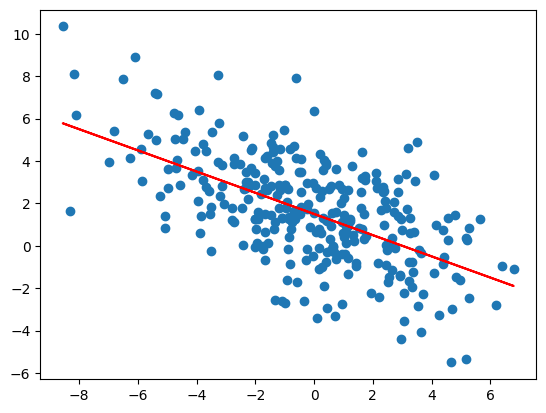

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 1], y_noise)
plt.plot(X[:, 1], y, color="red")

In [ ]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef

In [ ]:
dataset = np.hstack([X, y_noise[:, np.newaxis]])
dataset[:3, :]

array([[ 1.        , -1.10335995, -2.62318714],
       [ 1.        ,  0.58192326,  2.82600659],
       [ 1.        ,  1.73131137,  3.10115388]])

In [ ]:
res = regression_coeffs(dataset)
res

array([ 1.57545378, -0.50689414])

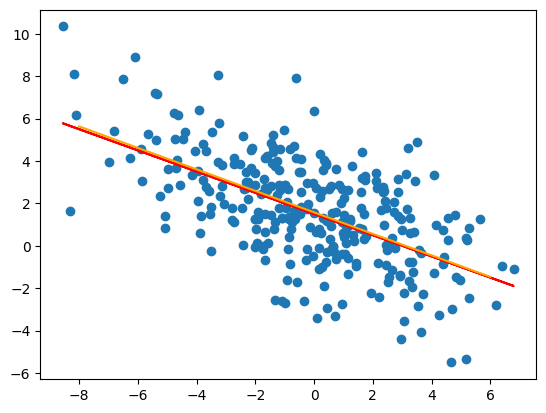

In [ ]:
plt.scatter(X[:, 1], y_noise)

test = np.array([[1, -8], [1, 6]])
plt.plot(X[:, 1], y, color="red")
plt.plot(test[:, 1], test @ res, color="orange")

In [ ]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)

ci = db.double_percentile_ci(confidence_level, seed=42, side="two", n_jobs=-1)


In [ ]:
print(ci)

estimate = [ 1.57545378 -0.50689414]
lower = [ 1.32731596 -0.59917996]
upper = [ 1.80754835 -0.42036916]
confidence level = 0.95, side = two


In [ ]:
# Mean over the axis 0
rng = np.random.default_rng(123)

dataset = rng.normal(4, 3, size=(1000, 5, 5))


def mean_mat(x):
    return np.mean(x, axis=0)


print(mean_mat(dataset))


[[3.97415827 4.05517178 3.98702731 3.8743683  4.053281  ]
 [3.85367802 4.04472862 3.90890697 3.97792991 4.09252102]
 [4.12935094 4.01554232 4.01457519 3.94975741 4.0721076 ]
 [4.142231   4.13575172 4.03679546 3.93236058 4.007144  ]
 [4.14654217 4.07239243 3.87138847 4.03090362 3.89220331]]


In [ ]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=mean_mat, resampler=resampler)
ci = db.double_percentile_ci(0.95, n_jobs=-1)
print(ci)

estimate = [[3.97415827 4.05517178 3.98702731 3.8743683  4.053281  ]
 [3.85367802 4.04472862 3.90890697 3.97792991 4.09252102]
 [4.12935094 4.01554232 4.01457519 3.94975741 4.0721076 ]
 [4.142231   4.13575172 4.03679546 3.93236058 4.007144  ]
 [4.14654217 4.07239243 3.87138847 4.03090362 3.89220331]]
lower = [[3.77362202 3.8391253  3.7985399  3.67838769 3.86108014]
 [3.66544456 3.85768043 3.70382929 3.77162729 3.91189718]
 [3.93331436 3.8104314  3.82373919 3.77523147 3.87858587]
 [3.94382559 3.96733094 3.81713319 3.76438675 3.81256082]
 [3.93988305 3.88767784 3.68601491 3.84723895 3.70786278]]
upper = [[4.17181908 4.26819745 4.17813818 4.07852841 4.23417286]
 [4.03828645 4.24398628 4.10091114 4.18836732 4.28271401]
 [4.31226522 4.22755575 4.20085297 4.12303919 4.26439781]
 [4.34559734 4.2977428  4.25238216 4.10060768 4.19022289]
 [4.34762907 4.25442607 4.06255168 4.2213056  4.06736329]]
confidence level = 0.95, side = two


In [ ]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=mean_mat, resampler=resampler)
ci = db.percentile_ci(0.95, n_jobs=-1)
print(ci)

estimate = [[3.97415827 4.05517178 3.98702731 3.8743683  4.053281  ]
 [3.85367802 4.04472862 3.90890697 3.97792991 4.09252102]
 [4.12935094 4.01554232 4.01457519 3.94975741 4.0721076 ]
 [4.142231   4.13575172 4.03679546 3.93236058 4.007144  ]
 [4.14654217 4.07239243 3.87138847 4.03090362 3.89220331]]
lower = [[3.77053851 3.86117368 3.78289307 3.68178047 3.87697474]
 [3.66612991 3.85781995 3.71421324 3.78905668 3.90063081]
 [3.94661475 3.83805666 3.82716016 3.76586054 3.89749062]
 [3.9456948  3.94263282 3.84533629 3.75103049 3.81268616]
 [3.94239003 3.89209559 3.68436916 3.84744973 3.70602006]]
upper = [[4.17310595 4.25527695 4.18851965 4.05757754 4.22033745]
 [4.03362423 4.21632915 4.09338914 4.17043652 4.27590621]
 [4.32024742 4.18571178 4.20308128 4.13209886 4.26275177]
 [4.33104567 4.31950675 4.22627636 4.10922597 4.18306868]
 [4.33779789 4.25758813 4.0606572  4.22001719 4.08043204]]
confidence level = 0.95, side = two


In [ ]:
import pandas as pd

rng = np.random.default_rng(123)

beta_gt = np.array([1, -0.5, -3, 2, 1.5])

dataset = pd.DataFrame(
    rng.normal(4, 3, size=(100, 5)),
    columns=[f"x{i}" for i in range(5)],
)
dataset["x0"] = 1.0
dataset["y"] = dataset.values @ beta_gt + rng.normal(0, 2, size=100)

dataset.head()

,x0,x1,x2,x3,x4,y
0,1.0,2.896640,7.863776,4.581923,6.760693,-9.465066
1,1.0,2.090609,5.625857,3.050214,3.032833,-5.764266
2,1.0,-0.577791,7.576498,1.986731,7.000808,-5.489898
3,1.0,8.596099,2.020092,3.064615,5.013307,6.230820
4,1.0,6.483764,8.624891,7.380420,6.264309,-0.841128


In [ ]:
def regression_coeffs(data):
    x = data[["x0", "x1", "x2", "x3", "x4"]].values
    y = data[["y"]].values

    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef


resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)
ci1 = db.double_percentile_ci(
    0.95, seed=42, n_jobs=-1, b1_resamples=1000, b2_resamples=1000
)

/var/folders/jk/7hrwm5nx04366_ckr1bbkpfc0000gn/T/ipykernel_21195/4049928270.py:11: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)


In [ ]:
ci1

ConfidenceInterval(estimate=array([[ 0.85829138],
       [-0.41453692],
       [-3.02184101],
       [ 2.08497249],
       [ 1.42186712]]), confidence_level=0.95, side='two', lower=array([[-0.06673543],
       [-0.56504291],
       [-3.15284131],
       [ 1.93797483],
       [ 1.27834318]]), upper=array([[ 1.89052539],
       [-0.27849686],
       [-2.88513836],
       [ 2.22785604],
       [ 1.55084449]]))

In [ ]:
rng = np.random.default_rng(123)

beta_gt = np.array([1, -0.5, -3, 2, 1.5])


def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]

    return np.linalg.lstsq(x, y, rcond=None)[0]


resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)
ci1 = db.double_percentile_ci(
    0.95, seed=42, n_jobs=-1, b1_resamples=1000, b2_resamples=1000
)

print(ci1)

estimate = [ 0.85829138 -0.41453692 -3.02184101  2.08497249  1.42186712]
lower = [-0.06673543 -0.56504291 -3.15284131  1.93797483  1.27834318]
upper = [ 1.89052539 -0.27849686 -2.88513836  2.22785604  1.55084449]
confidence level = 0.95, side = two


In [ ]:
print(type(dataset))

<class 'pandas.DataFrame'>


In [ ]:
resampler = IIDResampler(dataset)
db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)
ci1 = db.percentile_ci(0.95, seed=42, n_jobs=-1)
print(ci1)

estimate = [[ 0.85829138]
 [-0.41453692]
 [-3.02184101]
 [ 2.08497249]
 [ 1.42186712]]
lower = [[-0.12151948]
 [-0.57635313]
 [-3.15396386]
 [ 1.94622204]
 [ 1.2999804 ]]
upper = [[ 2.01768827]
 [-0.27838747]
 [-2.88647434]
 [ 2.22887916]
 [ 1.54398621]]
confidence level = 0.95, side = two


/var/folders/jk/7hrwm5nx04366_ckr1bbkpfc0000gn/T/ipykernel_96707/3298907779.py:2: UserWarning: Data sample is a pandas DataFrame. This introduces additional overhead during resampling. If performance is a concern, consider converting the DataFrame to a NumPy array before passing it to the resampler and updating the statistic.
  db = DoubleBootstrap(statistic=regression_coeffs, resampler=resampler)


In [ ]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef


data2 = dataset.values
db = DoubleBootstrap(statistic=regression_coeffs, resampler=IIDResampler(data2))
ci2 = db.double_percentile_ci(0.95, seed=42, n_jobs=-1)
print(ci2)

estimate = [ 0.85829138 -0.41453692 -3.02184101  2.08497249  1.42186712]
lower = [-0.20527564 -0.5674204  -3.14673549  1.93613784  1.27923942]
upper = [ 1.89266133 -0.27957173 -2.88097537  2.23219435  1.54995299]
confidence level = 0.95, side = two


In [ ]:
np.all(ci1.lower.flatten() == ci2.lower.flatten())

np.True_

In [ ]:
np.all(ci1.upper.flatten() == ci2.upper.flatten())

np.True_

In [ ]:
ci2

ConfidenceInterval(estimate=array([ 0.85829138, -0.41453692, -3.02184101,  2.08497249,  1.42186712]), confidence_level=0.95, side='two', lower=array([-0.20527564, -0.5674204 , -3.14673549,  1.93613784,  1.27923942]), upper=array([ 1.89266133, -0.27957173, -2.88097537,  2.23219435,  1.54995299]))

In [ ]:
data2 = dataset.values
db = DoubleBootstrap(statistic=regression_coeffs, resampler=IIDResampler(data2))
ci2 = db.percentile_ci(0.95, seed=42, n_jobs=-1)
print(ci2)

estimate = [ 0.85829138 -0.41453692 -3.02184101  2.08497249  1.42186712]
lower = [-0.12151948 -0.57635313 -3.15396386  1.94622204  1.2999804 ]
upper = [ 2.01768827 -0.27838747 -2.88647434  2.22887916  1.54398621]
confidence level = 0.95, side = two


In [ ]:
np.all(np.ravel(ci1.lower) == ci2.lower) and np.all(
    np.ravel(ci1.upper) == ci2.upper
)

np.True_

In [ ]:
dataset = dataset.values

In [ ]:
dataset_t = dataset.T


def regression_coeffs_t(data):
    x = data[:-1, :].T
    y = data[-1, :].T
    return np.linalg.lstsq(x, y, rcond=None)[0]


# Try out different data dimension
resampler = IIDResampler(dataset_t, axis=1)
db = DoubleBootstrap(statistic=regression_coeffs_t, resampler=resampler)
ci = db.double_percentile_ci(0.95, seed=42, side="two", n_jobs=-1)
print(ci)

estimate = [ 0.85829138 -0.41453692 -3.02184101  2.08497249  1.42186712]
lower = [-0.20527564 -0.5674204  -3.14673549  1.93613784  1.27923942]
upper = [ 1.89266133 -0.27957173 -2.88097537  2.23219435  1.54995299]
confidence level = 0.95, side = two
